# Experiment B — Multi-Modulation Device Fingerprinting
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi Madushani  
**Supervisor:** Prof. Qinghua Wang

---

## Two-part experiment

| Part | Description | Key question |
|---|---|---|
| B1 | Combined multi-modulation model | Can one CNN fingerprint devices across all 4 modulations? |
| B2 | Leave-one-modulation-out (LOMO) | Does the fingerprint transfer to an entirely unseen modulation? |

**Training strategy (carried over from Experiment A):**  
Multi-session (S1+S2) + noise augmentation (clean + SNR10 + SNR0)

**Modulations:** BPSK · QPSK · GFSK · OOK  
Note: QPSK and GFSK had unreliable CFO estimation in signal analysis — per-modulation results reported separately.

**Output directory:** `Models/ExperimentB/`

## Section 1 — Mount Drive + Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc

# ── Find the shared folder ─────────────────────────────────────────────────────
# Shared folders appear under Shared drives OR as a shortcut in MyDrive
# Run this to find it:
for root in ['/content/drive/MyDrive', '/content/drive/Shareddrives']:
    if os.path.exists(root):
        print(f'{root}: {os.listdir(root)}')

Mounted at /content/drive
/content/drive/MyDrive: ['Colab Notebooks']


In [ ]:
import os

# Check all possible locations
locations = [
    '/content/drive/MyDrive',
    '/content/drive/Shareddrives',
    '/content/drive/Shared drives',
]

for loc in locations:
    if os.path.exists(loc):
        print(f'\n{loc}:')
        for item in os.listdir(loc):
            print(f'  {item}')
    else:
        print(f'\n{loc}: does not exist')


/content/drive/MyDrive:
  Colab Notebooks

/content/drive/Shareddrives: does not exist

/content/drive/Shared drives: does not exist


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'My Thesis']


In [ ]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE         = '/content/drive/MyDrive/My Thesis'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
MODEL_DIR    = os.path.join(BASE, 'Models', 'ExperimentB')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Verify ─────────────────────────────────────────────────────────────────────
print(f'BASE contents    : {os.listdir(BASE)}')
print(f'Preprocessed S1  : {os.listdir(os.path.join(PREPROCESSED, "S1"))[:4]} ...')
print(f'ExperimentB dir  : {os.listdir(MODEL_DIR)}')

# ── Config ─────────────────────────────────────────────────────────────────────
MODULATIONS  = ['BPSK', 'QPSK', 'GFSK', 'OOK']
SESSIONS     = ['S1', 'S2']
AUG_TAGS     = ['clean', 'SNR10', 'SNR0']
EVAL_SNRS    = [None, 20, 10, 0]
BATCH_SIZE   = 256
MAX_EPOCHS   = 60
LR           = 1e-4
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

experiment_B_results = {}

print('\nSetup complete.')
print(f'TF version  : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU         : {gpus[0].name if gpus else "CPU only"}')

BASE contents    : ['Literature', 'My LR Drafts', 'midway-seminar prep.pptx', 'Simulations', 'Models', 'Recordings', 'GNU Radio', 'Notebooks', 'Preprocessed']
Preprocessed S1  : ['BPSK_SNR20_X.npy', 'BPSK_SNR20_y.npy', 'BPSK_SNR10_X.npy', 'BPSK_SNR10_y.npy'] ...
ExperimentB dir  : ['B1_combined_model.keras', 'B1_training_curves.png', 'B1_accuracy_heatmap.png', 'LOMO_BPSK_model.keras', 'B1_results_checkpoint.json', 'B1_eval_checkpoint.json']

Setup complete.
TF version  : 2.20.0
GPU         : /physical_device:GPU:0


## Section 2 — Shared Helpers

In [ ]:
def build_cnn(learning_rate=LR):
    """Identical architecture to Experiment A."""
    inp = keras.Input(shape=(128, 2), name='iq_input')
    x = layers.Conv1D(32,  kernel_size=7, padding='valid', activation='relu')(inp)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(64,  kernel_size=5, padding='valid', activation='relu')(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(128, kernel_size=3, padding='valid', activation='relu')(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks(ckpt_path):
    return [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ]


def load_npy(session, modulation, snr_tag):
    X = np.load(os.path.join(PREPROCESSED, session, f'{modulation}_{snr_tag}_X.npy'))
    y = np.load(os.path.join(PREPROCESSED, session, f'{modulation}_{snr_tag}_y.npy'))
    return X, y


def build_dataset(modulations, sessions, snr_tags, verbose=True):
    """
    Load and concatenate data for given modulations × sessions × SNR levels.
    Returns X (N, 128, 2) float32 and y (N,) int32.
    """
    parts_X, parts_y = [], []
    for mod in modulations:
        for sess in sessions:
            for tag in snr_tags:
                Xt, yt = load_npy(sess, mod, tag)
                parts_X.append(Xt)
                parts_y.append(yt)
                if verbose:
                    print(f'  Loaded {sess}/{mod}/{tag}: {Xt.shape[0]:,}')
    X = np.concatenate(parts_X)
    y = np.concatenate(parts_y)
    del parts_X, parts_y
    gc.collect()
    return X, y


def split_trainvaltest(X, y, test_frac=0.15, val_frac=0.15, seed=RANDOM_SEED):
    X_tv, X_te, y_tv, y_te = train_test_split(
        X, y, test_size=test_frac, stratify=y, random_state=seed)
    val_rel = val_frac / (1 - test_frac)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv, test_size=val_rel, stratify=y_tv, random_state=seed)
    return X_tr, X_val, X_te, y_tr, y_val, y_te


def evaluate_per_modulation(model, session='S2'):
    """
    Evaluate model on each modulation × SNR level independently.
    Returns nested dict: {modulation: {snr_tag: {accuracy, auc, loss}}}
    """
    results = {}
    for mod in MODULATIONS:
        results[mod] = {}
        for snr in EVAL_SNRS:
            tag  = 'clean' if snr is None else f'SNR{snr}'
            Xs, ys = load_npy(session, mod, tag)
            loss_, acc_ = model.evaluate(Xs, ys, batch_size=BATCH_SIZE, verbose=0)
            prob_ = model.predict(Xs, batch_size=BATCH_SIZE, verbose=0)
            fpr_, tpr_, _ = roc_curve(ys, prob_[:, 1])
            auc_ = float(auc(fpr_, tpr_))
            results[mod][tag] = {
                'accuracy': float(acc_),
                'loss'    : float(loss_),
                'auc'     : auc_
            }
            del Xs, ys, prob_
        gc.collect()
    return results


def snr_tag(snr):
    return 'clean' if snr is None else f'SNR{snr}'


print('Helpers defined.')

Helpers defined.


---
# Part B1 — Combined Multi-Modulation Model

**Training data:** S1 + S2 · all 4 modulations · clean + SNR10 + SNR0  
**Total windows:** 4 mod × 2 sess × 3 SNR × 100,000 = 2,400,000 → ~70% train = 1,680,000  
**Evaluation:** per-modulation × per-SNR on full S2

In [ ]:
print('=' * 60)
print('  B1 — Building combined multi-modulation dataset')
print('=' * 60)

X_b1, y_b1 = build_dataset(MODULATIONS, SESSIONS, AUG_TAGS)

print(f'\nCombined pool : {X_b1.shape[0]:,} windows')
print(f'DEV01 (0)     : {np.sum(y_b1==0):,}')
print(f'DEV02 (1)     : {np.sum(y_b1==1):,}')

X_tr_b1, X_val_b1, X_te_b1, y_tr_b1, y_val_b1, y_te_b1 = \
    split_trainvaltest(X_b1, y_b1)
del X_b1, y_b1
gc.collect()

print(f'\nTrain : {X_tr_b1.shape[0]:,}')
print(f'Val   : {X_val_b1.shape[0]:,}')
print(f'Test  : {X_te_b1.shape[0]:,}')

In [ ]:
print('Training B1 combined model...')
ckpt_b1  = os.path.join(MODEL_DIR, 'B1_combined_model.keras')
model_b1 = build_cnn()
model_b1.summary()

t0 = time.time()
hist_b1 = model_b1.fit(
    X_tr_b1, y_tr_b1,
    validation_data=(X_val_b1, y_val_b1),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(ckpt_b1),
    verbose=1
)
del X_tr_b1, X_val_b1, X_te_b1, y_tr_b1, y_val_b1, y_te_b1
gc.collect()

elapsed = (time.time() - t0) / 60
print(f'\nDone in {elapsed:.1f} min')
print(f'Best val acc: {max(hist_b1.history["val_accuracy"])*100:.2f}%')

In [ ]:
# B1 training curves
hist = hist_b1.history
best_ep = np.argmin(hist['val_loss']) + 1
epochs_ran = range(1, len(hist['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('B1 — Combined Multi-Modulation Model Training Curves', fontsize=12)

ax1.plot(epochs_ran, hist['loss'],     color='steelblue', label='Train')
ax1.plot(epochs_ran, hist['val_loss'], color='coral',     label='Val')
ax1.axvline(best_ep, linestyle='--', color='grey', linewidth=1,
            label=f'Best epoch ({best_ep})')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in hist['accuracy']],
         color='steelblue', label='Train')
ax2.plot(epochs_ran, [a*100 for a in hist['val_accuracy']],
         color='coral',     label='Val')
ax2.axvline(best_ep, linestyle='--', color='grey', linewidth=1,
            label=f'Best epoch ({best_ep})')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([50, 101])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
p = os.path.join(MODEL_DIR, 'B1_training_curves.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

In [ ]:
# B1 per-modulation evaluation on full S2
print('Evaluating B1 per-modulation on full S2...')
b1_eval = evaluate_per_modulation(model_b1, session='S2')
experiment_B_results['B1_combined'] = {
    'description': 'Single model trained on all 4 modulations, S1+S2, clean+SNR10+SNR0',
    'best_epoch' : int(best_ep),
    'val_accuracy': float(max(hist_b1.history['val_accuracy'])),
    'per_modulation_eval': b1_eval
}

# Summary table
snr_cols   = ['clean', 'SNR20', 'SNR10', 'SNR0']
print(f'\n  {"Modulation":<8}  {"Clean":>8}  {"SNR20":>8}  {"SNR10":>8}  {"SNR0":>8}')
print('  ' + '-' * 50)
for mod in MODULATIONS:
    row = [b1_eval[mod].get(c, {}).get('accuracy', 0) * 100 for c in snr_cols]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>6.2f}%' for v in row))

In [ ]:
# B1 heatmap — accuracy across modulations and SNR levels
snr_cols_plot   = ['clean', 'SNR20', 'SNR10', 'SNR0']
snr_labels_plot = ['Clean\n(∞ dB)', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']

acc_matrix = np.array([
    [b1_eval[mod].get(c, {}).get('accuracy', 0) * 100
     for c in snr_cols_plot]
    for mod in MODULATIONS
])

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(acc_matrix, cmap='RdYlGn', vmin=50, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy (%)')

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(snr_labels_plot, fontsize=10)
ax.set_yticklabels(MODULATIONS, fontsize=11)
ax.set_xlabel('Evaluation SNR level')
ax.set_title('B1 — Combined Model: Accuracy per Modulation × SNR\n'
             '(Evaluated on Full S2)', fontweight='bold')

for i in range(4):
    for j in range(4):
        v = acc_matrix[i, j]
        color = 'white' if v < 75 else 'black'
        ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
p = os.path.join(MODEL_DIR, 'B1_accuracy_heatmap.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

In [ ]:
# Re-run Section 1 (mount + setup) and Section 2 (helpers) first
# Then reload B1 results instead of retraining:

import json
model_b1 = keras.models.load_model(
    os.path.join(MODEL_DIR, 'B1_combined_model.keras'))

with open(os.path.join(MODEL_DIR, 'B1_eval_checkpoint.json')) as f:
    b1_eval = json.load(f)

experiment_B_results['B1_combined'] = {
    'per_modulation_eval': b1_eval
}

print('B1 restored — ready to continue with B2')

B1 restored — ready to continue with B2


---
# Part B2 — Leave-One-Modulation-Out (LOMO)

**4 training rounds.** In each round, one modulation is held out completely from training.  
The trained model is then evaluated on the held-out modulation.

**Key question:** Does the device fingerprint transfer to a modulation the CNN has never seen?

| Round | Train on | Test on (held out) |
|---|---|---|
| LOMO-BPSK | QPSK + GFSK + OOK | BPSK |
| LOMO-QPSK | BPSK + GFSK + OOK | QPSK |
| LOMO-GFSK | BPSK + QPSK + OOK | GFSK |
| LOMO-OOK  | BPSK + QPSK + GFSK | OOK |

All training uses S1+S2, clean+SNR10+SNR0.

In [ ]:
print('=' * 60)
print('  B2 — Leave-One-Modulation-Out')
print('=' * 60)

lomo_results = {}   # held_out_mod → {snr_tag → {accuracy, auc}}

for held_out in MODULATIONS:
    train_mods = [m for m in MODULATIONS if m != held_out]
    print(f'\n── LOMO-{held_out}: train on {train_mods}, test on {held_out} ──')

    # Build training dataset (3 modulations)
    X_lomo, y_lomo = build_dataset(train_mods, SESSIONS, AUG_TAGS, verbose=False)
    print(f'  Training pool: {X_lomo.shape[0]:,} windows')

    X_tr, X_val, X_te, y_tr, y_val, y_te = split_trainvaltest(X_lomo, y_lomo)
    del X_lomo, y_lomo
    gc.collect()

    print(f'  Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_te.shape[0]:,}')

    # Train
    ckpt_lomo  = os.path.join(MODEL_DIR, f'LOMO_{held_out}_model.keras')
    model_lomo = build_cnn()

    t0 = time.time()
    hist_lomo = model_lomo.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(ckpt_lomo),
        verbose=1
    )
    del X_tr, X_val, X_te, y_tr, y_val, y_te
    gc.collect()

    elapsed = (time.time() - t0) / 60
    best_val = max(hist_lomo.history['val_accuracy']) * 100
    print(f'  Done in {elapsed:.1f} min  |  Best val acc: {best_val:.2f}%')

    # Evaluate on held-out modulation across all SNR levels (full S2)
    print(f'  Evaluating on held-out {held_out}...')
    held_out_results = {}
    for snr in EVAL_SNRS:
        tag = snr_tag(snr)
        Xs, ys = load_npy('S2', held_out, tag)
        loss_, acc_ = model_lomo.evaluate(Xs, ys, batch_size=BATCH_SIZE, verbose=0)
        prob_ = model_lomo.predict(Xs, batch_size=BATCH_SIZE, verbose=0)
        fpr_, tpr_, _ = roc_curve(ys, prob_[:, 1])
        auc_ = float(auc(fpr_, tpr_))
        held_out_results[tag] = {
            'accuracy': float(acc_),
            'loss'    : float(loss_),
            'auc'     : auc_
        }
        snr_label = 'clean' if snr is None else f'SNR {snr} dB'
        print(f'    {held_out} {snr_label:<12}: acc={acc_*100:.2f}%  AUC={auc_:.4f}')
        del Xs, ys, prob_
    gc.collect()

    lomo_results[held_out] = {
        'train_modulations': train_mods,
        'best_val_accuracy': float(best_val / 100),
        'held_out_eval'    : held_out_results
    }
    del model_lomo
    gc.collect()

experiment_B_results['B2_LOMO'] = lomo_results
print('\nAll LOMO rounds complete.')

  B2 — Leave-One-Modulation-Out

── LOMO-BPSK: train on ['QPSK', 'GFSK', 'OOK'], test on BPSK ──
  Training pool: 1,800,000 windows
  Train: 1,260,000  Val: 270,000  Test: 270,000
Epoch 1/60
4922/4922 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.6548 - loss: 0.5617 - val_accuracy: 0.7221 - val_loss: 0.4703 - learning_rate: 1.0000e-04
Epoch 2/60
4922/4922 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.7338 - loss: 0.4448 - val_accuracy: 0.7667 - val_loss: 0.4050 - learning_rate: 1.0000e-04
Epoch 3/60
4922/4922 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.7701 - loss: 0.3922 - val_accuracy: 0.7951 - val_loss: 0.3614 - learning_rate: 1.0000e-04
Epoch 4/60
4922/4922 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.7955 - loss: 0.3558 - val_accuracy: 0.8138 - val_loss: 0.3279 - learning_rate: 1.0000e-04
Epoch 5/60
4922/4922 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.8095 - loss: 0.3332 - val_accuracy: 0.8277 - val_loss: 0.3085 - learning_rate: 1.0000e-04
Epoch 6/60
4922/4922 ━━━━

In [ ]:
# B2 LOMO clean accuracy summary table
snr_cols_lomo   = ['clean', 'SNR20', 'SNR10', 'SNR0']
snr_labels_lomo = ['Clean (∞ dB)', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']

print(f'\n  LOMO Results — accuracy on held-out modulation (full S2)')
print(f'  {"Held-out":<8}  {"Clean":>10}  {"SNR20":>10}  {"SNR10":>10}  {"SNR0":>10}')
print('  ' + '-' * 55)
for mod in MODULATIONS:
    row = [lomo_results[mod]['held_out_eval'].get(c, {}).get('accuracy', 0) * 100
           for c in snr_cols_lomo]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>8.2f}%' for v in row))


  LOMO Results — accuracy on held-out modulation (full S2)
  Held-out       Clean       SNR20       SNR10        SNR0
  -------------------------------------------------------
  BPSK         53.25%     53.35%     53.51%     54.48%
  QPSK         38.75%     38.75%     39.02%     40.00%
  GFSK         63.20%     63.28%     63.48%     62.08%
  OOK          51.06%     51.04%     50.99%     50.53%


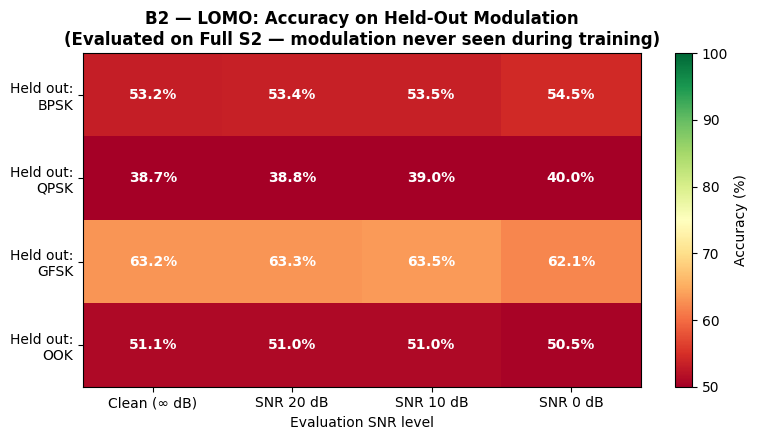

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentB/B2_LOMO_heatmap.png


In [ ]:
# B2 LOMO heatmap — clean accuracy for each held-out modulation
lomo_acc_matrix = np.array([
    [lomo_results[mod]['held_out_eval'].get(c, {}).get('accuracy', 0) * 100
     for c in snr_cols_lomo]
    for mod in MODULATIONS
])

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(lomo_acc_matrix, cmap='RdYlGn', vmin=50, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy (%)')

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(snr_labels_lomo, fontsize=10)
ax.set_yticklabels([f'Held out:\n{m}' for m in MODULATIONS], fontsize=10)
ax.set_xlabel('Evaluation SNR level')
ax.set_title('B2 — LOMO: Accuracy on Held-Out Modulation\n'
             '(Evaluated on Full S2 — modulation never seen during training)',
             fontweight='bold')

for i in range(4):
    for j in range(4):
        v = lomo_acc_matrix[i, j]
        color = 'white' if v < 75 else 'black'
        ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
p = os.path.join(MODEL_DIR, 'B2_LOMO_heatmap.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

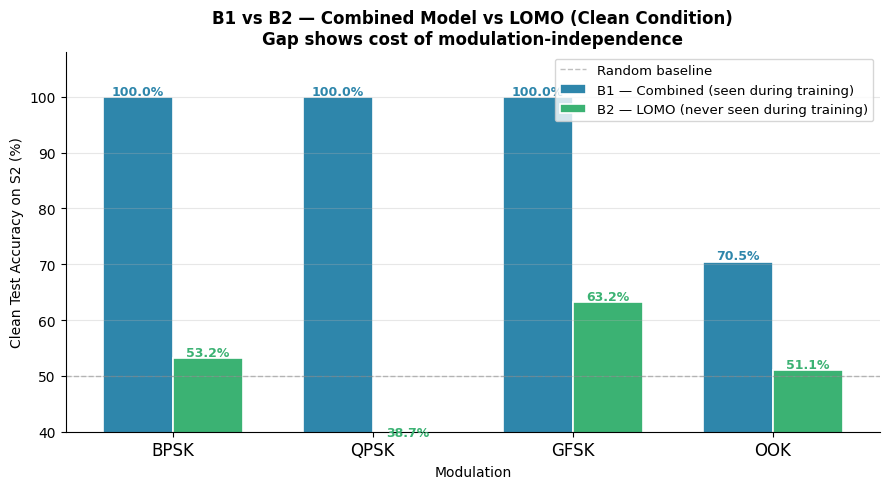

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentB/B2_B1_vs_LOMO_clean.png


In [ ]:
# B2 LOMO line chart — clean accuracy comparison B1 vs LOMO per modulation
b1_clean  = [b1_eval[m]['clean']['accuracy'] * 100 for m in MODULATIONS]
lomo_clean = [lomo_results[m]['held_out_eval']['clean']['accuracy'] * 100
              for m in MODULATIONS]

x = np.arange(len(MODULATIONS))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, b1_clean,  width, label='B1 — Combined (seen during training)',
               color='#2E86AB', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, lomo_clean, width, label='B2 — LOMO (never seen during training)',
               color='#3BB273', edgecolor='white', linewidth=1.2)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9,
            fontweight='bold', color='#2E86AB')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9,
            fontweight='bold', color='#3BB273')

ax.axhline(50, linestyle='--', color='grey', linewidth=1, alpha=0.5,
           label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(MODULATIONS, fontsize=12)
ax.set_ylabel('Clean Test Accuracy on S2 (%)')
ax.set_xlabel('Modulation')
ax.set_title('B1 vs B2 — Combined Model vs LOMO (Clean Condition)\n'
             'Gap shows cost of modulation-independence',
             fontweight='bold')
ax.set_ylim([40, 108])
ax.legend(fontsize=9.5)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
p = os.path.join(MODEL_DIR, 'B2_B1_vs_LOMO_clean.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 10 — Save Results + Final Summary

In [ ]:
json_path = os.path.join(MODEL_DIR, 'experiment_B_results.json')
with open(json_path, 'w') as f:
    json.dump(experiment_B_results, f, indent=2)

print(f'Results saved: {json_path}')
print()
print('═' * 65)
print('  EXPERIMENT B SUMMARY')
print('═' * 65)

print('\nB1 — Combined model (all 4 modulations, clean test on S2):')
print(f'  {"Modulation":<8}  {"Clean":>8}  {"SNR20":>8}  {"SNR10":>8}  {"SNR0":>8}')
print('  ' + '-' * 50)
for mod in MODULATIONS:
    row = [b1_eval[mod].get(c, {}).get('accuracy', 0) * 100
           for c in snr_cols_plot]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>6.2f}%' for v in row))

print('\nB2 — LOMO (held-out modulation, clean test on S2):')
print(f'  {"Held-out":<8}  {"Clean":>8}  {"SNR20":>8}  {"SNR10":>8}  {"SNR0":>8}')
print('  ' + '-' * 50)
for mod in MODULATIONS:
    row = [lomo_results[mod]['held_out_eval'].get(c, {}).get('accuracy', 0) * 100
           for c in snr_cols_lomo]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>6.2f}%' for v in row))

print('═' * 65)
print(f'\nAll plots saved to: {MODEL_DIR}')
print('\nFiles produced:')
for fn in sorted(os.listdir(MODEL_DIR)):
    if fn.endswith(('.png', '.json', '.keras')):
        size = os.path.getsize(os.path.join(MODEL_DIR, fn)) / 1024
        print(f'  {fn:<45} {size:>7.1f} KB')

Results saved: /content/drive/MyDrive/My Thesis/Models/ExperimentB/experiment_B_results.json

═════════════════════════════════════════════════════════════════
  EXPERIMENT B SUMMARY
═════════════════════════════════════════════════════════════════

B1 — Combined model (all 4 modulations, clean test on S2):
  Modulation     Clean     SNR20     SNR10      SNR0
  --------------------------------------------------


NameError: name 'snr_cols_plot' is not defined

In [ ]:
# Fix for summary cell — redefine the missing variable then rerun summary
snr_cols_plot  = ['clean', 'SNR20', 'SNR10', 'SNR0']
snr_cols_lomo  = ['clean', 'SNR20', 'SNR10', 'SNR0']

print('═' * 65)
print('  EXPERIMENT B SUMMARY')
print('═' * 65)

print('\nB1 — Combined model (all 4 modulations, clean test on S2):')
print(f'  {"Modulation":<8}  {"Clean":>8}  {"SNR20":>8}  {"SNR10":>8}  {"SNR0":>8}')
print('  ' + '-' * 50)
for mod in MODULATIONS:
    row = [b1_eval[mod].get(c, {}).get('accuracy', 0) * 100
           for c in snr_cols_plot]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>6.2f}%' for v in row))

print('\nB2 — LOMO (held-out modulation, clean test on S2):')
print(f'  {"Held-out":<8}  {"Clean":>8}  {"SNR20":>8}  {"SNR10":>8}  {"SNR0":>8}')
print('  ' + '-' * 50)
for mod in MODULATIONS:
    row = [lomo_results[mod]['held_out_eval'].get(c, {}).get('accuracy', 0) * 100
           for c in snr_cols_lomo]
    print(f'  {mod:<8}  ' + '  '.join(f'{v:>6.2f}%' for v in row))

print('═' * 65)


═════════════════════════════════════════════════════════════════
  EXPERIMENT B SUMMARY
═════════════════════════════════════════════════════════════════

B1 — Combined model (all 4 modulations, clean test on S2):
  Modulation     Clean     SNR20     SNR10      SNR0
  --------------------------------------------------
  BPSK      100.00%  100.00%  100.00%   99.95%
  QPSK       99.98%   99.73%   98.23%   97.85%
  GFSK      100.00%  100.00%   99.93%   98.36%
  OOK        70.46%   70.46%   70.35%   64.91%

B2 — LOMO (held-out modulation, clean test on S2):
  Held-out     Clean     SNR20     SNR10      SNR0
  --------------------------------------------------
  BPSK       53.25%   53.35%   53.51%   54.48%
  QPSK       38.75%   38.75%   39.02%   40.00%
  GFSK       63.20%   63.28%   63.48%   62.08%
  OOK        51.06%   51.04%   50.99%   50.53%
═════════════════════════════════════════════════════════════════
